# Task A3 — Parameter Robustness Assessment
### How sensitive is the Relative Risk metric to analysis parameter choices?

#### 1. Imports and paths

In [11]:
from pathlib import Path
import sys
import subprocess
import json

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
DATA_PATH = PROJECT_ROOT / "data" / "single-cell-tracks_exp1-6_noErbB2.csv.gz"
META_PATH = PROJECT_ROOT / "data" / "01-readme-experiment-description_2022-04-05.csv"

OUTPUT_ROOT = PROJECT_ROOT / "analysis_outputs"
FINAL_OUTPUT_DIR = PROJECT_ROOT / "outputs"

OUTPUT_ROOT.mkdir(exist_ok=True)
FINAL_OUTPUT_DIR.mkdir(exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA exists:", DATA_PATH.exists())
print("META exists:", META_PATH.exists())
print("SCRIPT exists:", (SCRIPTS_DIR / "spatiotemporal_signal_propagation.py").exists())

PROJECT_ROOT: /home/m/biologiaSystemów/projekt2
DATA exists: True
META exists: True
SCRIPT exists: True


#### 2. Analysis settings

In [12]:
EXP_ID = 1
SITE_ID = 1
SIGNAL_COL = "ERKKTR_ratio"

SPATIAL_RADIUS = 60
JUMP_QUANTILE = 0.9

windows = [1, 3, 6, 12]

#### 3.  Generate future-window parameter sweep
For each tested value of `W`, the spatiotemporal propagation script is run separately.  
Each run creates a corresponding `sweep_w*` folder in `analysis_outputs/`.


In [13]:
for w in windows:
    outdir = OUTPUT_ROOT / f"sweep_w{w}"
    
    cmd = [
        sys.executable,
        str(SCRIPTS_DIR / "spatiotemporal_signal_propagation.py"),
        "--data-path", str(DATA_PATH),
        "--meta-path", str(META_PATH),
        "--exp-id", str(EXP_ID),
        "--site-id", str(SITE_ID),
        "--signal-col", SIGNAL_COL,
        "--spatial-radius", str(SPATIAL_RADIUS),
        "--future-window-frames", str(w),
        "--jump-quantile", str(JUMP_QUANTILE),
        "--output-dir", str(outdir),
    ]
    
    print(f"Running sweep for W={w} frames...")
    result = subprocess.run(cmd, capture_output=True, text=True)
    
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(f"Sweep failed for W={w}")
    
    print(result.stdout[-400:])

Running sweep for W=1 frames...
same cell shows such a large upward change within the next 1 frames.
Future jump rate with neighbour jump now: 0.06450688855544946
Future jump rate without neighbour jump now: 0.03357427194636497
Risk difference: 0.030932616609084494 (absolute probability gap; 0.05 means 5 percentage points higher).
Relative risk: 1.921319058191328 (times more likely; 1 means no difference, >1 means more likely).

Running sweep for W=3 frames...
same cell shows such a large upward change within the next 3 frames.
Future jump rate with neighbour jump now: 0.13145546310189607
Future jump rate without neighbour jump now: 0.07486715044854579
Risk difference: 0.05658831265335028 (absolute probability gap; 0.05 means 5 percentage points higher).
Relative risk: 1.7558496926130764 (times more likely; 1 means no difference, >1 means more likely).

Running sweep for W=6 frames...
 same cell shows such a large upward change within the next 6 frames.
Future jump rate with neighbour 

#### 4. Verify sweep folders exist

In [ ]:
for w in windows:
    folder = OUTPUT_ROOT / f"sweep_w{w}"
    summary_path = (
        folder /
        f"exp_{EXP_ID}_site_{SITE_ID}_{SIGNAL_COL}" /
        "summary.json"
    )
    
    print(f"W={w}: folder exists = {folder.exists()}, summary exists = {summary_path.exists()}")

W=1: folder exists = True, summary exists = True
W=3: folder exists = True, summary exists = True
W=6: folder exists = True, summary exists = True
W=12: folder exists = True, summary exists = True


#### 5. Extract RR from summary.json files

In [ ]:
rows = []

for w in windows:
    summary_path = (
        OUTPUT_ROOT /
        f"sweep_w{w}" /
        f"exp_{EXP_ID}_site_{SITE_ID}_{SIGNAL_COL}" /
        "summary.json"
    )
    
    with open(summary_path) as f:
        s = json.load(f)
    
    rows.append({
        "future_window_frames": w,
        "future_window_min": w * 5,
        "RR": s["relative_risk"],
        "theta": s["jump_threshold"],
        "p_exposed": s["future_jump_rate_if_neighbor_jumps_now"],
        "p_unexposed": s["future_jump_rate_if_no_neighbor_jumps_now"],
        "risk_difference": s["risk_difference"],
        "n_spatial_edges": s["n_spatial_edges"],
        "n_nodes": s["n_nodes"],
    })

robustness_df = pd.DataFrame(rows)
display(robustness_df)

,future_window_frames,future_window_min,RR,theta,p_exposed,p_unexposed,risk_difference,n_spatial_edges,n_nodes
0,1,5,1.921319,0.036543,0.064507,0.033574,0.030933,2389504,356632
1,3,15,1.755850,0.036543,0.131455,0.074867,0.056588,2389504,356632
2,6,30,1.586293,0.036543,0.203608,0.128355,0.075253,2389504,356632
3,12,60,1.384017,0.036543,0.305804,0.220954,0.084850,2389504,356632


#### 6. Save extracted robustness table

In [ ]:
robustness_df.to_csv(
    FINAL_OUTPUT_DIR / "parameter_robustness_window_sweep.csv",
    index=False
)

print("Saved:")
print(FINAL_OUTPUT_DIR / "parameter_robustness_window_sweep.csv")

Saved:
/home/m/biologiaSystemów/projekt2/outputs/parameter_robustness_window_sweep.csv


#### 7. Visualizing parameter robustness
Plot RR vs future window

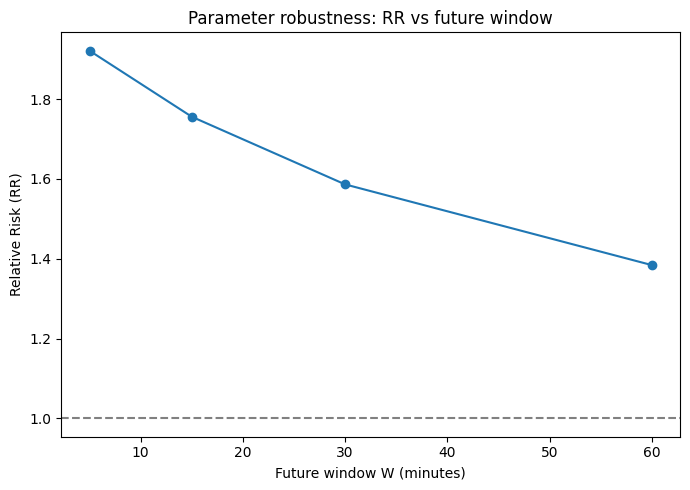

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    robustness_df["future_window_min"],
    robustness_df["RR"],
    marker="o"
)

ax.axhline(
    1,
    linestyle="--",
    color="gray"
)

ax.set_xlabel("Future window W (minutes)")
ax.set_ylabel("Relative Risk (RR)")
ax.set_title("Parameter robustness: RR vs future window")

plt.tight_layout()

plt.savefig(
    FINAL_OUTPUT_DIR / "parameter_robustness_window_sweep.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()